# Predicting Reservation Cancellations

**CIS 8005 · October 2026**

**Research question:** Can recorded reservation details identify bookings at higher risk of cancellation, and is that ranking useful enough to warrant testing targeted confirmation outreach?


## Overview

Imagine a hotel has a list of upcoming reservations. We want to sort that list by estimated cancellation risk so staff could consider contacting a manageable number of guests. Each record in the synthetic dataset is a **reservation**, and `booking_status = 1` means it canceled.

There are two separate questions: **Can we predict cancellations?** and **Would contacting a predicted high-risk guest improve anything?** The analysis addresses the first question. The second would require a separate test of guest contact.


| Part | Sections | Question |
|---|---:|---|
| The reservations | 1–3 | What is in the dataset, what looks unusual, and which patterns stand out? |
| The prediction test | 4–6 | How were models compared, and how reliable are their risk scores? |
| From scores to decisions | 7–9 | What would an alert rule require from staff and from the available data? |
| Reality checks | 10–11 | How does the selected approach perform on held-out rows and across arrival years? |
| Recommendation | 12 | What must be verified before testing guest contact in practice? |

**Central distinction:** Identifying reservations that may cancel is different from showing that contacting those guests would prevent cancellations.


## 1. Research design and scope of inference

We estimate the retrospective association

$$p(x)=P(Y=1\mid X=x),\qquad Y=1\text{ denotes cancellation.}$$

The unit of analysis is one **synthetic reservation record**. A proposed hotel decision is whether to contact a reservation at a specified scoring time. The data do not contain verified feature histories, contact assignments or treatment outcomes.

| Claim | What the data support | What remains unmeasured |
|---|---|---|
| Prediction | Ranking observed cancellations within this sample | Performance on genuinely new hotel bookings |
| Probability estimation | Reliability diagnostics on reserved rows | Stability after a change in hotel or period |
| Decision policy | Workload and error penalties under explicit assumptions | Actual staffing costs and intervention effects |
| Causal benefit | A prospective study design | Cancellations prevented or revenue recovered |


### Prediction and the proposed decision

**When is a score made?** The available data provide one retrospective snapshot. Scoring at booking creation is an assumption; no contact schedule or repeated scoring is evaluated. `lead_time` is available when the reservation is created; prior-booking counts require an existing history, and special requests may be entered later. The data do not show when those fields were recorded.

**Working assumption:** score at booking creation. Historical outcome counts and special requests are eligible only if their recorded values existed then. This assumption is unresolved in the source data.

For an actual hotel, a defensible workflow would score every reservation **immediately at creation using only fields verified to exist then**. Near-arrival bookings would enter the daily review queue immediately. Far-ahead bookings could be reviewed closer to arrival and scored again if timestamped updates are available. The review horizon should be chosen with staff capacity and a prospective test, not assumed from this dataset. We cannot estimate the benefit of waiting or rescoring from these static records.


In [5]:
# Libraries for data, plots, splitting, models, and evaluation.
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance


In [6]:
# Use the repository root and one fixed seed for reproducible figures.
ROOT = Path.cwd()
if not (ROOT / 'data/raw/train.csv').is_file():
    raise FileNotFoundError('Open and run this notebook from the repository root.')
OUT = ROOT / 'graduate_results'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 42
COLORS = {'navy': '#15344A', 'teal': '#167E88', 'amber': '#B46721',
          'gray': '#647780', 'light': '#E6EEF2'}
plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 170, 'font.size': 12,
    'axes.titlesize': 15, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlepad': 14,
})
pd.set_option('display.max_columns', 20)

def finish(fig, filename):
    """Save the evidence figure and display it inside the notebook."""
    fig.savefig(OUT / filename, bbox_inches='tight')
    plt.show()


In [7]:
# Confirm the target and row IDs before creating any model features.
raw = pd.read_csv(ROOT / 'data/raw/train.csv')
assert raw['booking_status'].isin([0, 1]).all()
assert raw['id'].is_unique
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'sklearn': sklearn.__version__}
print('Environment:', versions)
print(f'Raw data: {raw.shape[0]:,} rows and {raw.shape[1]} columns')
_ = (OUT / 'versions.json').write_text(json.dumps(versions, indent=2))


Environment: {'python': '3.12.4', 'numpy': '1.26.4', 'pandas': '3.0.6', 'sklearn': '1.4.2'}
Raw data: 42,100 rows and 19 columns


## 2. Data quality and defensible transformation

These reservations come from Kaggle Playground Series S3E7, a synthetic dataset generated from earlier reservation data.

**Cleaning principle:** preserve uncertain observations and expose their condition. Deleting every zero-price or invalid-date row would impose an unsupported interpretation of how the records arose.


In [10]:
# Add simple totals and indicators while preserving original fields.
def add_features(frame):
    frame = frame.copy()
    frame['total_guests'] = frame.no_of_adults + frame.no_of_children
    frame['total_nights'] = frame.no_of_weekend_nights + frame.no_of_week_nights
    arrival = pd.to_datetime({'year': frame.arrival_year,
                             'month': frame.arrival_month,
                             'day': frame.arrival_date}, errors='coerce')
    frame['invalid_arrival_date'] = arrival.isna().astype(int)
    frame['zero_guests'] = frame.total_guests.eq(0).astype(int)
    frame['zero_nights'] = frame.total_nights.eq(0).astype(int)
    frame['zero_room_price'] = frame.avg_price_per_room.eq(0).astype(int)
    return frame


In [11]:
# Count data-quality patterns before deciding whether to transform them.
train = add_features(raw)
assert train[raw.columns].equals(raw)  # Original values remain unchanged.
y = train['booking_status'].astype(int)
X = train.drop(columns=['id', 'booking_status'])
categories = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
flags = ['invalid_arrival_date', 'zero_guests', 'zero_nights', 'zero_room_price']
predictor_columns = raw.drop(columns=['id', 'booking_status']).columns.tolist()
predictor_groups = raw.groupby(predictor_columns, dropna=False).booking_status.agg(['size', 'sum'])
opposing_pairs = ((predictor_groups['size'] == 2) & (predictor_groups['sum'] == 1)).sum()
audit = pd.DataFrame({'condition': ['Missing cells', 'Exact duplicates excluding ID',
                                    'Identical predictors, opposite-label pairs', *flags],
                     'count': [raw.isna().sum().sum(), raw.drop(columns='id').duplicated().sum(),
                               opposing_pairs, *train[flags].sum().tolist()]})
display(audit)


,condition,count
0,Missing cells,0
1,Exact duplicates excluding ID,0
2,"Identical predictors, opposite-label pairs",562
3,invalid_arrival_date,50
4,zero_guests,16
5,zero_nights,114
6,zero_room_price,641


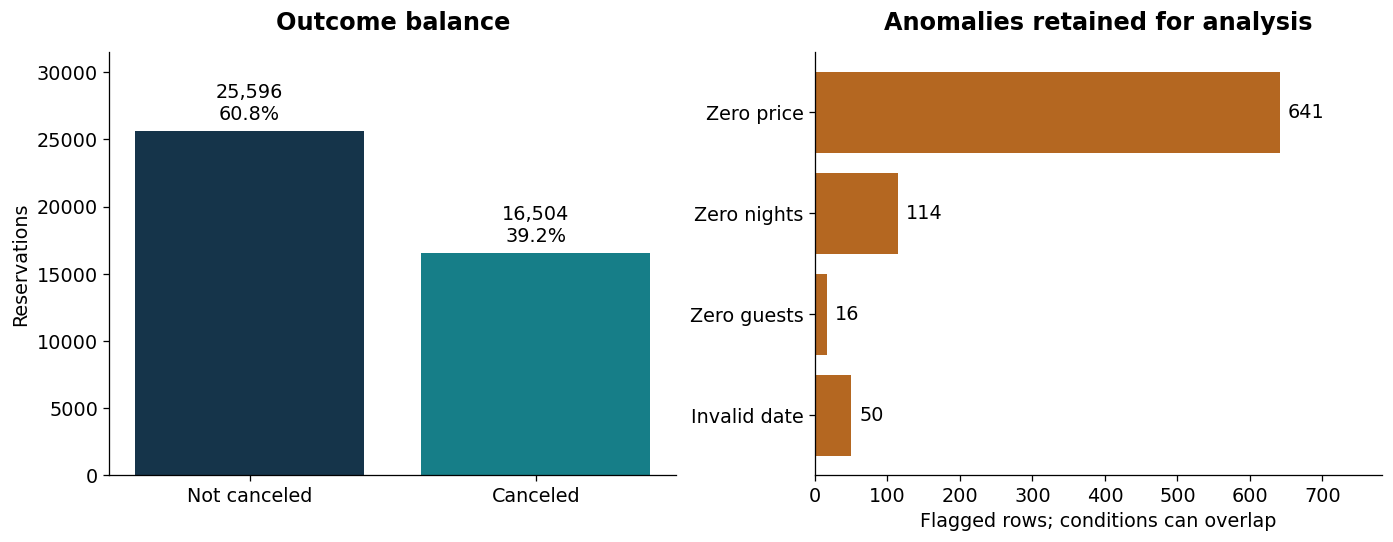

In [12]:
# Show class balance and anomaly frequency side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
counts = y.value_counts().reindex([0, 1])
bars = axes[0].bar(['Not canceled', 'Canceled'], counts,
                   color=[COLORS['navy'], COLORS['teal']])
axes[0].bar_label(bars, labels=[f'{n:,}\n{n/len(y):.1%}' for n in counts], padding=5)
axes[0].set_ylim(0, counts.max()*1.23)
axes[0].set_ylabel('Reservations')
axes[0].set_title('Outcome balance')
flag_counts = train[flags].sum()
bars = axes[1].barh(['Invalid date', 'Zero guests', 'Zero nights', 'Zero price'],
                    flag_counts, color=COLORS['amber'])
axes[1].bar_label(bars, padding=5)
axes[1].set_xlim(0, flag_counts.max()*1.22)
axes[1].set_xlabel('Flagged rows; conditions can overlap')
axes[1].set_title('Anomalies retained for analysis')
finish(fig, '01_data_audit.png')


### Data quality decisions

| Finding | How many? | Treatment in the analysis |
|---|---:|---|
| Impossible arrival date | 50 | Keeps the original year/month/day and adds an `invalid_arrival_date` flag. |
| Zero room price | 641 | Keeps the price and adds a `zero_room_price` flag. |
| Zero guests / zero nights | 16 / 114 | Keeps the counts and adds flags. |
| Same predictors, opposite outcomes | 562 pairs | Keeps both reservations and reports the pattern. |

**These indicators identify unusual records; they do not repair the original values.** They remain available to the model, and later sensitivity analyses test the added fields together and zero-price rows separately. The group test shows little average-precision benefit; the zero-price check supports retaining those rows and their indicator. We do not replace invalid dates with guessed values or delete the other unusual records because their intended values are unknown.

**Interpretation.** Of 42,100 reservations, 16,504 (39.2%) canceled and 25,596 (60.8%) did not. This makes accuracy alone insufficient for evaluating cancellation risk. The anomaly counts overlap and must not be added to obtain a unique-row total. The 562 predictor-identical pairs have opposite outcomes: the earlier exact-duplicate check kept the outcome column, so it correctly returned zero for a different question. We retain these rows, but matching predictors across partitions can complicate interpretation of a random split.

**Method choice.** Impossible dates are marked rather than guessed. Added totals and flags use only information already in each row; their predictive value is tested later.

## 3. Descriptive evidence and uncertainty

Lead time has a strong observed relationship with cancellation. We show counts alongside rates and Wilson intervals to avoid presenting small groups as equally precise.

These intervals are **binomial summaries under an independent-observation assumption**. Synthetic generation, unobserved dependence and selection limit their interpretation as population uncertainty. They do not account for confounding.

In [121]:
# Group bookings by how far ahead they were made, then count cancellations.
lead_band = pd.cut(train.lead_time, [-1, 7, 30, 90, 180, 365, np.inf],
                   labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+'])
lead = train.groupby(lead_band, observed=True).booking_status.agg(
    n='size', canceled='sum', rate='mean')

display(lead.round(4))


,n,canceled,rate
lead_time,,,
0–7,4435,486,0.1096
8–30,4598,1023,0.2225
31–90,11576,2946,0.2545
91–180,14298,7141,0.4994
181–365,7002,4761,0.6799
366+,191,147,0.7696


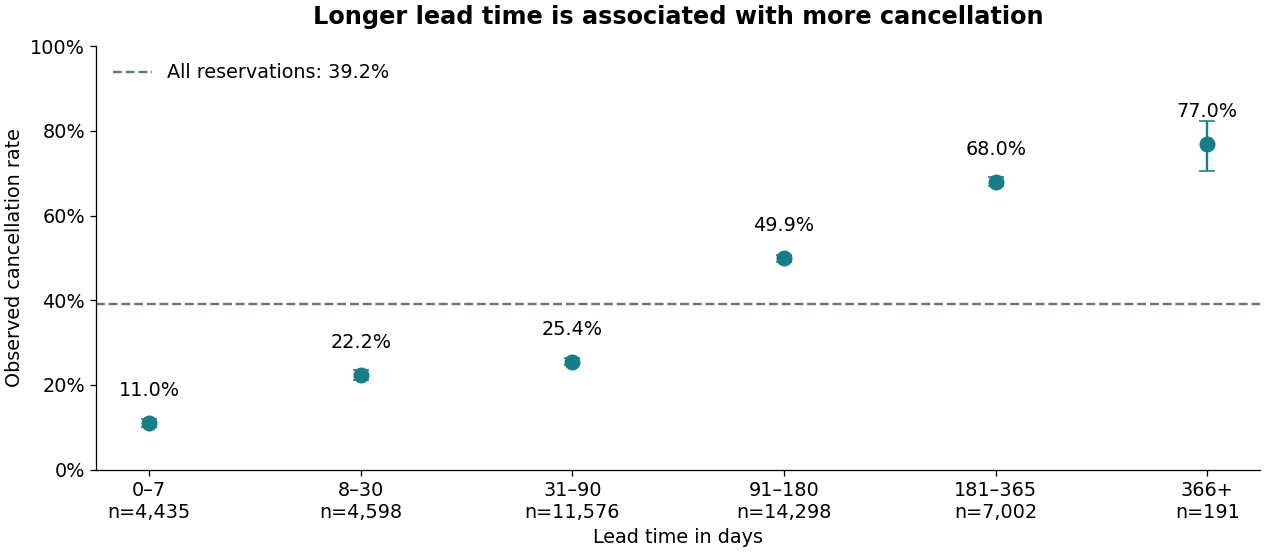

In [17]:
# Show cancellation rates with Wilson intervals for each lead-time group.
def wilson(successes, n, z=1.96):
    """Wilson interval for a binomial proportion, assuming independent rows."""
    rate = successes / n
    denom = 1 + z*z/n
    center = (rate + z*z/(2*n)) / denom
    half = z*np.sqrt(rate*(1-rate)/n + z*z/(4*n*n)) / denom
    return center-half, center+half

lo, hi = wilson(lead.canceled, lead.n)
fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
positions = np.arange(len(lead))
overall_rate = y.mean()
ax.axhline(overall_rate, linestyle='--', linewidth=1.5,
           color=COLORS['gray'], label=f'All reservations: {overall_rate:.1%}')
ax.errorbar(positions, lead.rate, yerr=[lead.rate-lo, hi-lead.rate],
            fmt='o', markersize=9, capsize=5, color=COLORS['teal'])
ax.set_xticks(positions, [f'{label}\nn={n:,}' for label, n in zip(lead.index, lead.n)])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel('Lead time in days')
ax.set_ylabel('Observed cancellation rate')
ax.set_title('Longer lead time is associated with more cancellation')
ax.legend(loc='upper left', frameon=False)
for i, rate in enumerate(lead.rate):
    ax.annotate(f'{rate:.1%}', (i, rate), xytext=(0, 17),
                textcoords='offset points', ha='center')
finish(fig, '02_lead_time_uncertainty.png')


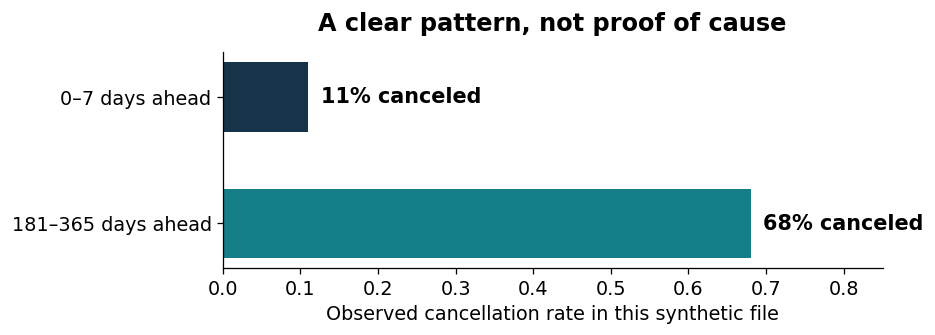

In [18]:
# Two-booking-horizon view of the lead-time table above.
comparison = lead.loc[['0–7', '181–365']]
fig, ax = plt.subplots(figsize=(8, 2.8), constrained_layout=True)
bars = ax.barh(['0–7 days ahead', '181–365 days ahead'], comparison['rate'],
               color=['#15344A', '#167E88'], height=0.55)
ax.bar_label(bars, labels=[f'{rate:.0%} canceled' for rate in comparison['rate']],
             padding=8, fontsize=13, weight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 0.85)
ax.set_xlabel('Observed cancellation rate in this synthetic file')
ax.set_title('A clear pattern, not proof of cause')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

### Lead time and observed cancellation

| Booking lead time | Reservations | Canceled | Interpretation |
|---|---:|---:|---|
| **0–7 days before arrival** | 4,435 | **11%** | Roughly 11 of 100 such bookings canceled. |
| **181–365 days before arrival** | 7,002 | **68%** | Roughly 68 of 100 such bookings canceled. |

Across all **42,100 reservations**, **16,504 canceled (39.2%)**. The dashed line marks that overall rate as a reference for the lead-time groups.

Longer lead time is a strong **pattern** in these records. It does **not** prove that booking earlier causes cancellation: the two groups may also differ in travel plans, prices, market segment, or other ways. A multivariable model then checks whether the pattern helps prediction alongside other fields.

**Discussion.** Cancellation increases from approximately 11% for 0–7 days to 68% for 181–365 days. The 366+ day group has only 191 rows. Price, market segment, calendar period and guest behavior may confound these comparisons. A multivariable model assesses prediction without assigning a causal effect to lead time.

**Method choice.** Fixed lead-time bands make the pattern readable. The plotted Wilson intervals communicate sampling uncertainty without extending below 0% or above 100%.

## 4. Validation architecture and leakage controls

The analysis uses 60% fitting, 20% threshold validation and 20% final random holdout, with stratification on the outcome. Three-fold cross-validation inside the fitting partition compares model families.

**Evaluation limit:** Earlier exploration inspected all labeled rows and evaluated the random holdout. This holdout is therefore not a fresh, independent confirmation. Threshold and capacity analyses use validation rows; holdout outcomes do not select a new policy.

Preprocessing belongs inside each training fold. Category encoding, imputation and scaling must learn from that fold's fitting rows only.

In [22]:
# Reserve fitting, cutoff-selection, and final-evaluation rows.
X_dev, X_hold, y_dev, y_hold = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert set(X_fit.index).isdisjoint(X_val.index)
assert set(X_dev.index).isdisjoint(X_hold.index)
split_summary = pd.DataFrame([
    {'partition': name, 'rows': len(labels), 'cancellation_rate': labels.mean()}
    for name, labels in [('training', y_fit), ('validation', y_val), ('holdout', y_hold)]
])
display(split_summary)
split_summary.to_csv(OUT / 'split_summary.csv', index=False)


,partition,rows,cancellation_rate
0,training,25260,0.392003
1,validation,8420,0.392043
2,holdout,8420,0.392043


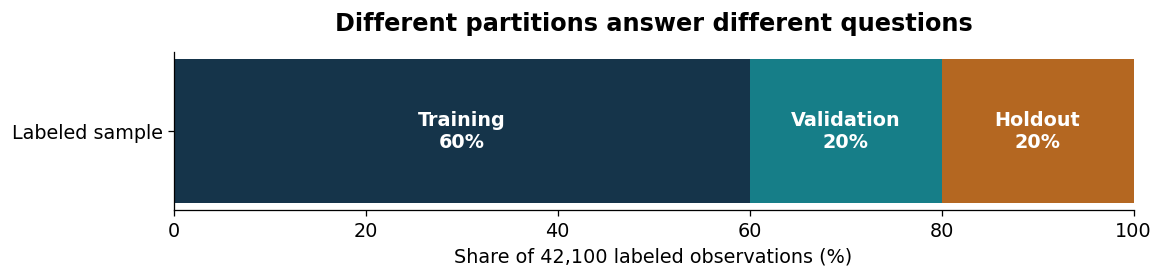

In [23]:
# Visualize the 60/20/20 allocation.
fig, ax = plt.subplots(figsize=(10, 2.3), constrained_layout=True)
left = 0
for name, amount, color in [('Training', 60, COLORS['navy']),
                             ('Validation', 20, COLORS['teal']),
                             ('Holdout', 20, COLORS['amber'])]:
    ax.barh(['Labeled sample'], [amount], left=left, color=color, height=0.45)
    ax.text(left+amount/2, 0, f'{name}\n{amount}%', ha='center', va='center', color='white', weight='bold')
    left += amount
ax.set_xlim(0, 100)
ax.set_xlabel('Share of 42,100 labeled observations (%)')
ax.set_title('Different partitions answer different questions')
finish(fig, '03_validation_design.png')


### Why the data are split

Picture 100 labeled reservations. About **60** train and compare models, **20** help choose when a score should trigger an alert, and **20** are used for the final reported check. Inside the first 60, three-fold cross-validation repeatedly fits on part of that group and checks the rest.

This division limits how often we make decisions using the same answers we later report as evidence. It is still a **random, retrospective** check, and earlier exploration saw the full dataset; the holdout is not fresh independent confirmation.

**Why this design?** The two splits allocate 60% of labeled rows to model fitting, 20% to choosing the alert cutoff, and 20% to evaluating the selected approach. Stratification keeps cancellation rates similar across those groups. The partitions contain no overlapping rows.


## 5. Model specification and comparison

We compare a prevalence-only baseline with regularized logistic regression, a depth-limited decision tree and a random forest. Logistic regression offers an additive relationship on the log-odds scale. Trees can capture nonlinear thresholds and interactions. The forest averages across randomized trees to reduce instability.

**Selection criterion:** mean training-fold average precision (AP). AP is a recall-weighted summary of precision, not accuracy and not the same as trapezoidal PR area. Its baseline depends on prevalence. Fixed hyperparameters limit the search but do not establish the best possible model.

| Choice | Reason | Limitation |
|---|---|---|
| One-hot category encoding | Avoid unsupported numerical ordering | More columns, unknown levels need handling |
| Numeric standardization | Makes logistic regularization more comparable across scales | Does not make effects causal |
| Minimum tree leaf sizes | Restricts very small terminal groups | Hyperparameters are illustrative |
| Three stratified folds | Applies a common comparison design | Fold scores are correlated, with limited precision |

In [27]:
# Fit imputation, scaling, and category encoding inside each training fold.
from sklearn.metrics import make_scorer

def make_preprocessor(columns):
    cats = [c for c in categories if c in columns]
    nums = [c for c in columns if c not in cats]
    return ColumnTransformer([
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), nums),
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cats),
    ])

def make_model(estimator, columns):
    return Pipeline([('prepare', make_preprocessor(columns)),
                     ('model', clone(estimator))])


In [28]:
# Compare the same four fixed model families with the same folds.
estimators = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic regression': LogisticRegression(max_iter=3000, C=1.0),
    'Decision tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=30,
                                           random_state=SEED),
    'Random forest': RandomForestClassifier(n_estimators=150,
        min_samples_leaf=5, max_features='sqrt', random_state=SEED, n_jobs=1),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
scoring = {'roc_auc': 'roc_auc', 'average_precision': 'average_precision',
           'recall': 'recall', 'precision': make_scorer(precision_score, zero_division=0),
           'neg_brier': 'neg_brier_score'}


**Why use a pipeline?** Numerical and categorical fields need different preparation. The pipeline learns imputation, scaling, and encoding inside each training fold, so a validation fold cannot influence those steps. The dummy model gives a no-skill reference, while the other three models test increasingly flexible relationships. Tree leaf-size limits restrain very small splits; all settings are fixed before comparison.


In [30]:
# Choose the model by training-fold average precision only.
cv_rows = []
fold_scores = {}
for name, estimator in estimators.items():
    result = cross_validate(make_model(estimator, X.columns), X_fit, y_fit,
                            cv=cv, scoring=scoring, n_jobs=1)
    fold_scores[name] = result['test_average_precision']
    cv_rows.append({
        'model': name,
        'mean_AP': result['test_average_precision'].mean(),
        'sd_AP': result['test_average_precision'].std(ddof=1),
        'mean_ROC_AUC': result['test_roc_auc'].mean(),
        'mean_precision_at_0.5': result['test_precision'].mean(),
        'mean_recall_at_0.5': result['test_recall'].mean(),
        'mean_Brier': -result['test_neg_brier'].mean(),
    })
comparison = pd.DataFrame(cv_rows).set_index('model').sort_values('mean_AP', ascending=False)
display(comparison)
comparison.to_csv(OUT / 'training_cv_comparison.csv')
winner = comparison.drop(index='Dummy')['mean_AP'].idxmax()
best = make_model(estimators[winner], X.columns).fit(X_fit, y_fit)
print('Selected by training CV:', winner)
p_val = best.predict_proba(X_val)[:, 1]
p_hold = best.predict_proba(X_hold)[:, 1]


,mean_AP,sd_AP,mean_ROC_AUC,mean_precision_at_0.5,mean_recall_at_0.5,mean_Brier
model,,,,,,
Random forest,0.830338,0.002829,0.883923,0.788533,0.720662,0.134342
Decision tree,0.791281,0.004424,0.860172,0.768322,0.713796,0.144302
Logistic regression,0.767816,0.007620,0.843196,0.726434,0.682589,0.156366
Dummy,0.392003,0.000069,0.500000,0.000000,0.000000,0.238337


Selected by training CV: Random forest


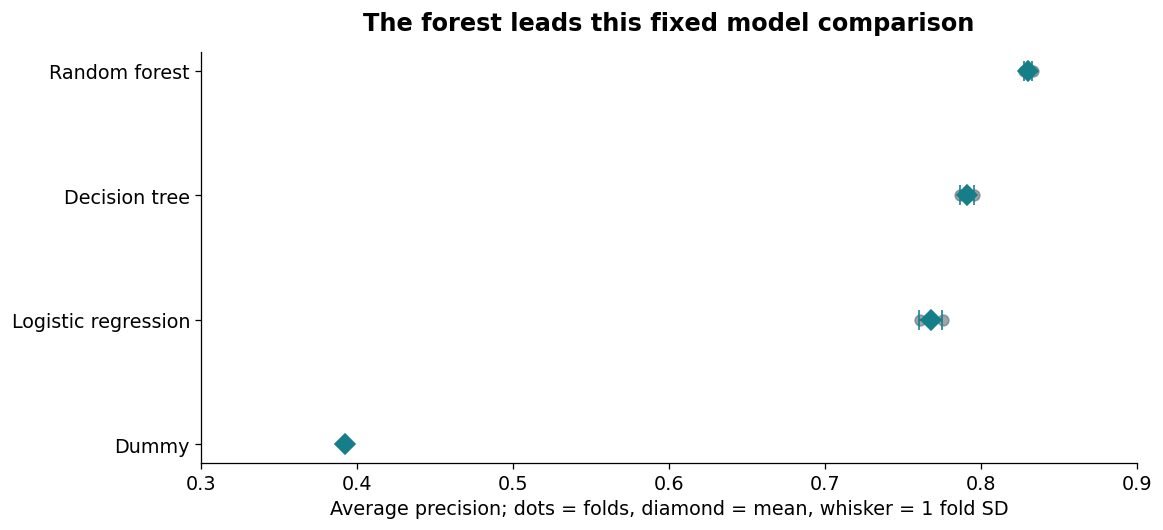

In [31]:
# Plot each fold score so the spread is visible.
order = comparison.index[::-1]
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
for j, name in enumerate(order):
    scores = fold_scores[name]
    ax.scatter(scores, np.full(len(scores), j), color=COLORS['gray'], alpha=.65, s=45)
    ax.errorbar(scores.mean(), j, xerr=scores.std(ddof=1), fmt='D',
                color=COLORS['teal'], capsize=6, markersize=9)
ax.set_yticks(range(len(order)), order)
ax.set_xlim(.3, .9)
ax.set_xlabel('Average precision; dots = folds, diamond = mean, whisker = 1 fold SD')
ax.set_title('The forest leads this fixed model comparison')
finish(fig, '04_model_comparison.png')


### Model comparison

The dummy model mainly reflects the overall cancellation rate; it has no useful ordering of individual bookings. Logistic regression uses a relatively simple formula. A decision tree makes a sequence of splits. A random forest averages many trees.

The random forest's training-fold **average precision was 0.830**, compared with **0.392** for the dummy. Average precision asks whether actual cancellations tend to appear near the top when we sort reservations from highest to lowest predicted risk. This comparison chose the forest from the four tested approaches; it does not prove it is the best possible model.

### Sensitivity check: repeated predictor patterns

There are 562 pairs with identical predictors but opposite outcomes. In the random 60/20/20 split, 322 pairs land in different partitions. We therefore repeat a **sensitivity check** that keeps identical predictor rows in one fold or partition. This tests how much the random split depends on those row patterns. Opposite labels also mean that sharing a pattern does not automatically make the prediction easy.

This is an exploratory check after model selection. It does not replace the holdout evaluation or select a new alert cutoff.


In [34]:
from sklearn.model_selection import StratifiedGroupKFold

# Give rows with identical original predictors one group ID; exclude ID and outcome.
groups = raw.groupby(predictor_columns, dropna=False).ngroup()
group_membership = pd.Series(groups, index=raw.index)
partition = pd.Series('holdout', index=raw.index)
partition.loc[X_fit.index] = 'fitting'
partition.loc[X_val.index] = 'validation'
pair_rows = raw.groupby(predictor_columns, dropna=False).booking_status.transform('size').eq(2)
opposite_rows = pair_rows & raw.groupby(predictor_columns, dropna=False).booking_status.transform('sum').eq(1)
pair_partitions = partition.loc[opposite_rows].groupby(group_membership.loc[opposite_rows]).nunique()
display(pd.DataFrame({'measure': ['opposite-label pairs', 'pairs crossing random partitions'],
                      'count': [int(opposing_pairs), int(pair_partitions.gt(1).sum())]}))


,measure,count
0,opposite-label pairs,562
1,pairs crossing random partitions,322


In [35]:
# Recheck the selected model on the same fitting rows, changing only fold membership.
group_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
group_fold_indices = list(group_cv.split(X_fit, y_fit, group_membership.loc[X_fit.index]))
random_result = cross_validate(make_model(estimators[winner], X.columns), X_fit, y_fit,
                               cv=cv, scoring=['average_precision', 'roc_auc'], n_jobs=1)
group_result = cross_validate(make_model(estimators[winner], X.columns), X_fit, y_fit,
                              cv=group_fold_indices, scoring=['average_precision', 'roc_auc'], n_jobs=1)
group_cv_comparison = pd.DataFrame([
    {'fold design': name, 'mean_AP': result['test_average_precision'].mean(),
     'mean_ROC_AUC': result['test_roc_auc'].mean()}
    for name, result in [('ordinary stratified', random_result),
                         ('identical predictors together', group_result)]
])
display(group_cv_comparison)
group_cv_comparison.to_csv(OUT / 'grouped_cv_sensitivity.csv', index=False)


,fold design,mean_AP,mean_ROC_AUC
0,ordinary stratified,0.830338,0.883923
1,identical predictors together,0.831533,0.884411


In [36]:
# Repeat the holdout split with groups intact, then compare ranking only.
# This is a new exploratory partition, not a second untouched test set.
whole_group_folds = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
                         .split(X, y, group_membership))
fit_index = np.concatenate([whole_group_folds[i][1] for i in range(3)])
group_hold_index = whole_group_folds[4][1]
assert set(group_membership.iloc[fit_index]).isdisjoint(group_membership.iloc[group_hold_index])
group_model = make_model(estimators[winner], X.columns).fit(X.iloc[fit_index], y.iloc[fit_index])
group_prob = group_model.predict_proba(X.iloc[group_hold_index])[:, 1]
group_holdout_comparison = pd.DataFrame([
    {'split': 'original random holdout', 'evaluation_rows': len(y_hold),
     'cancellation_rate': y_hold.mean(), 'AP': average_precision_score(y_hold, p_hold),
     'ROC_AUC': roc_auc_score(y_hold, p_hold)},
    {'split': 'grouped exploratory holdout', 'evaluation_rows': len(group_hold_index),
     'cancellation_rate': y.iloc[group_hold_index].mean(),
     'AP': average_precision_score(y.iloc[group_hold_index], group_prob),
     'ROC_AUC': roc_auc_score(y.iloc[group_hold_index], group_prob)},
])
display(group_holdout_comparison)
group_holdout_comparison.to_csv(OUT / 'grouped_holdout_sensitivity.csv', index=False)


,split,evaluation_rows,cancellation_rate,AP,ROC_AUC
0,original random holdout,8420,0.392043,0.835472,0.888322
1,grouped exploratory holdout,8424,0.393162,0.833163,0.886930


**Result.** Grouped and ordinary scores are close in this run, which reduces concern that repeated predictor patterns alone explain the ranking result. This does not resolve the contradictory labels or the larger questions of feature timing and generalization. The holdout comparisons use different partitions, so their small score difference is descriptive rather than a measured improvement.


**Interpretation.** The random forest ranks first, followed by the decision tree, logistic regression and dummy baseline. Fold standard deviations describe variation across these folds, not confidence intervals or a formal test of superiority.

**Model selection.** Average precision is calculated within the fitting partition's three folds. The forest is chosen from those results and then fitted on all 25,260 fitting rows. The final holdout does not choose the model.

## 6. Discrimination and probability reliability

ROC and precision-recall curves evaluate ranking across possible cutoffs. A reliability plot compares average predicted risk with the observed fraction canceled within bins.

**Interpretive distinction:** Brier score measures overall probability error and reflects both calibration and discrimination. A lower Brier score alone does not establish better calibration. No probability-calibration model is fitted here.

Reference: [scikit-learn probability calibration](https://scikit-learn.org/stable/modules/calibration.html).

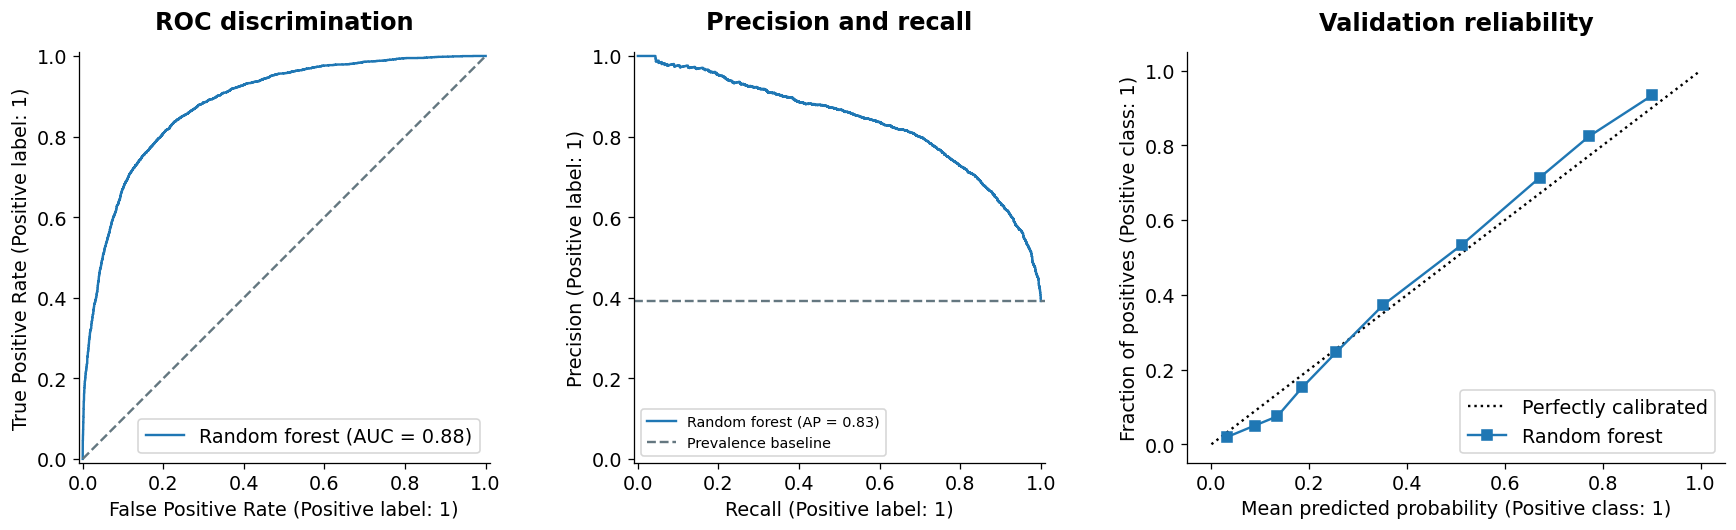

Validation Brier score: 0.1340


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
RocCurveDisplay.from_predictions(y_val, p_val, ax=axes[0], name=winner)
axes[0].plot([0, 1], [0, 1], '--', color=COLORS['gray'], label='Random ranking')
axes[0].set_title('ROC discrimination')
PrecisionRecallDisplay.from_predictions(y_val, p_val, ax=axes[1], name=winner)
axes[1].axhline(y_val.mean(), ls='--', color=COLORS['gray'], label='Prevalence baseline')
axes[1].legend(fontsize=9)
axes[1].set_title('Precision and recall')
CalibrationDisplay.from_predictions(y_val, p_val, n_bins=10, strategy='quantile',
                                   ax=axes[2], name=winner)
axes[2].set_title('Validation reliability')
finish(fig, '05_probability_diagnostics.png')
print(f'Validation Brier score: {brier_score_loss(y_val, p_val):.4f}')

### Reading the model diagnostics

- **ROC plot:** Can the model generally rank a canceled booking above a booking that did not cancel?
- **Precision–recall plot:** As we flag more bookings, how many flagged bookings really cancel, and how many cancellations do we find?
- **Reliability plot:** When the model says “about 40% risk,” do roughly 40% of those bookings cancel?

A good ranking does not automatically mean the percentages are trustworthy. The Brier score summarizes probability error, but it does not by itself prove perfect calibration.

**Reading the reliability plot.** Each bin groups reservations with similar predicted risk. Points near the diagonal have observed cancellation rates close to their average predicted probabilities. Bins can hide variation within a group; this chart is a diagnostic, not a fitted recalibration. Any future calibration would require a new training-only procedure and fresh evaluation.


## 7. Decision thresholds encode assumptions

For an alert rule $a_t(x)=\mathbf{1}[p(x)\ge t]$, the illustrative empirical loss is

$$L(t)=C_{FP}\,FP(t)+C_{FN}\,FN(t).$$

The illustrative policy uses $C_{FP}=1$ and $C_{FN}=5$. These are **assumed error penalties**, not money, prevented cancellations or measured contact benefits. Correct classifications carry zero loss in this simplified model.

If probabilities were perfectly calibrated and those were the true constant losses, the theoretical cutoff would be

$$t^*=\frac{C_{FP}}{C_{FP}+C_{FN}}=\frac{1}{6}\approx0.167.$$

We retain the empirically selected validation cutoff from the predeclared validation grid search. Finite data and probability errors can make that cutoff differ from the idealized value. Results under other penalty ratios show sensitivity to these assumptions; they do not create a new holdout-selected policy.

In [44]:
# Translate probabilities into alert decisions and confusion counts.
def metric_row(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, zero_division=0),
        'recall': recall_score(labels, predictions, zero_division=0),
        'F1': f1_score(labels, predictions, zero_division=0),
        'ROC_AUC': roc_auc_score(labels, probabilities),
        'AP': average_precision_score(labels, probabilities),
        'Brier': brier_score_loss(labels, probabilities),
        'alert_rate': predictions.mean(), 'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp),
    }


In [45]:
# Use validation rows to choose a cutoff under the stated 5:1 cost assumption.
thresholds = np.r_[np.linspace(0, 1, 201), np.nextafter(1.0, 2.0)]
threshold_rows = []
for t in thresholds:
    pred = p_val >= t
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    threshold_rows.append({'threshold': t, 'FP': fp, 'FN': fn,
                           'alert_rate': pred.mean(), 'loss': fp + 5 * fn})
threshold_table = pd.DataFrame(threshold_rows)
# For tied loss, prefer fewer contacts.
chosen = threshold_table.sort_values(['loss', 'alert_rate']).iloc[0]
threshold = float(chosen['threshold'])
display(chosen.to_frame('chosen validation policy'))
threshold_table.to_csv(OUT / 'validation_thresholds.csv', index=False)


,chosen validation policy
threshold,0.180000
FP,2404.000000
FN,162.000000
alert_rate,0.658314
loss,3214.000000


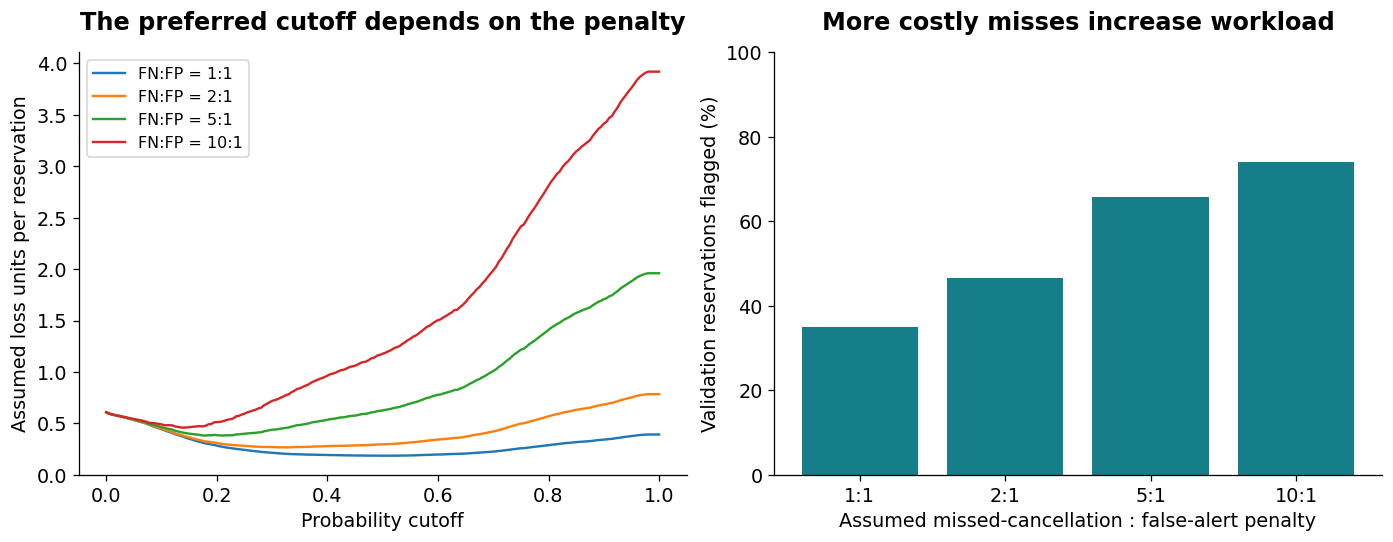

,FN:FP penalty,validation cutoff,validation alert rate
0,1:1,0.515,0.350
1,2:1,0.330,0.465
2,5:1,0.180,0.658
3,10:1,0.140,0.741


In [46]:
# Change the assumed cost ratio to show why the chosen cutoff is conditional.
ratios = [1, 2, 5, 10]
cost_sensitivity = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ratio in ratios:
    curve = threshold_table.FP + ratio * threshold_table.FN
    selected = (threshold_table.assign(scenario_loss=curve)
                .sort_values(['scenario_loss', 'alert_rate']).iloc[0])
    cost_sensitivity.append({'FN:FP penalty': f'{ratio}:1',
                             'validation cutoff': selected.threshold,
                             'validation alert rate': selected.alert_rate})
    axes[0].plot(threshold_table.threshold, curve/len(y_val), label=f'FN:FP = {ratio}:1')
axes[0].set_xlabel('Probability cutoff')
axes[0].set_ylabel('Assumed loss units per reservation')
axes[0].set_title('The preferred cutoff depends on the penalty')
axes[0].legend(fontsize=10)
scenario = pd.DataFrame(cost_sensitivity)
axes[1].bar(scenario['FN:FP penalty'], 100*scenario['validation alert rate'], color=COLORS['teal'])
axes[1].set_ylim(0, 100)
axes[1].set_xlabel('Assumed missed-cancellation : false-alert penalty')
axes[1].set_ylabel('Validation reservations flagged (%)')
axes[1].set_title('More costly misses increase workload')
finish(fig, '06_cost_assumptions.png')
display(scenario.round(3))


### What the 0.18 cutoff means

The model returns a risk score for each booking. An **alert cutoff** says which scores are high enough to flag. Here we *assume* that missing a cancellation is five times as costly as a false alert, then choose the cutoff that gives the lowest assumed loss on the validation group. The selected cutoff is **0.18**.

**0.18 is not a discovered hotel policy.** The 5:1 costs were invented for illustration, and a different cost ratio gives a different cutoff. The data contain no measured call cost, staffing limit, canceled-room cost, or evidence that a call prevents cancellation.

**How the decision rule is chosen.** A grid of cutoffs, including a rule that alerts nobody, is evaluated using false alerts and missed cancellations on the validation rows. It selects the cutoff with the lowest loss under the stated 5:1 penalty; ties favor fewer alerts.

This is an illustrative scenario. Calling the cutoff operationally optimal would require measured costs, staff capacity, and evidence about whether contact prevents cancellations.


## 8. Capacity constraints and risk prioritization

A fixed probability threshold can produce more alerts than staff can process. A capacity policy instead ranks reservations and reviews only the highest-risk fraction of an eligible cohort.

The following **exploratory validation analysis** compares recall, precision and cumulative gains at different capacities. It assumes all reservations in the cohort can be ranked together and contacts have equal resource cost. In practice, cohorts should reflect daily eligible bookings, and benefit may vary independently of cancellation risk.

In [50]:
# Sort validation bookings by score and summarize several review capacities.
# Stable sorting makes ties reproducible. This is a batch ranking illustration.
ranked = np.argsort(-p_val, kind='stable')
capacity_rows = []
for fraction in [.05, .10, .20, .30, .50, 1.0]:
    k = max(1, int(np.ceil(fraction*len(y_val))))
    caught = y_val.to_numpy()[ranked[:k]].sum()
    capacity_rows.append({'review share': k/len(y_val), 'contacts': k,
                          'precision': caught/k, 'recall': caught/y_val.sum(),
                          'lift over random': (caught/k)/y_val.mean()})
capacity = pd.DataFrame(capacity_rows)

display(capacity.round(3))
capacity.to_csv(OUT/'validation_capacity.csv', index=False)


,review share,contacts,precision,recall,lift over random
0,0.05,421,0.974,0.124,2.484
1,0.10,842,0.933,0.238,2.381
2,0.20,1684,0.879,0.448,2.242
3,0.30,2526,0.824,0.630,2.101
4,0.50,4210,0.676,0.862,1.724
5,1.00,8420,0.392,1.000,1.000


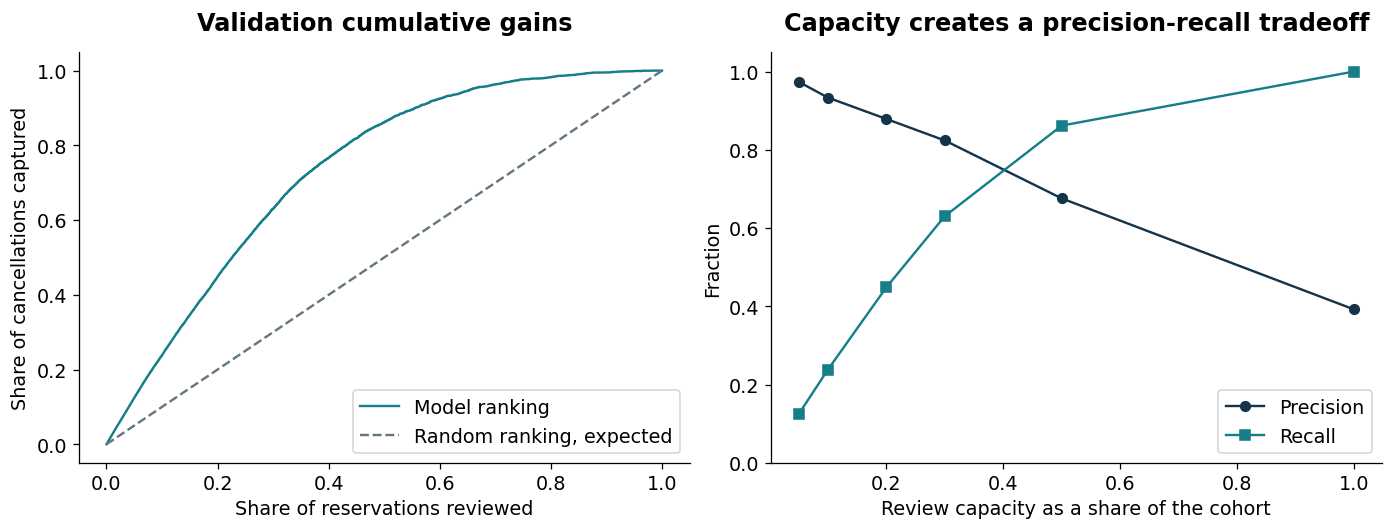

In [51]:
# Show how many cancellations a limited review queue could cover.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
review_share = np.arange(1, len(y_val)+1)/len(y_val)
cumulative_recall = np.cumsum(y_val.to_numpy()[ranked])/y_val.sum()
axes[0].plot(review_share, cumulative_recall, color=COLORS['teal'], label='Model ranking')
axes[0].plot([0,1], [0,1], '--', color=COLORS['gray'], label='Random ranking, expected')
axes[0].set(xlabel='Share of reservations reviewed', ylabel='Share of cancellations captured',
            title='Validation cumulative gains')
axes[0].legend()
axes[1].plot(capacity['review share'], capacity.precision, 'o-', label='Precision', color=COLORS['navy'])
axes[1].plot(capacity['review share'], capacity.recall, 's-', label='Recall', color=COLORS['teal'])
axes[1].set(xlabel='Review capacity as a share of the cohort', ylabel='Fraction', ylim=(0,1.05),
            title='Capacity creates a precision-recall tradeoff')
axes[1].legend()
finish(fig, '07_capacity_tradeoffs.png')


### Contact workload

At the chosen cutoff, the selected rule flags **66.3%** of reservations. A hotel processing 100 eligible bookings would need to review about **66** of them. That could be far more than staff can contact.

The capacity chart asks a different practical question: *If staff can contact only the top 10% or 20% of bookings, how many eventual cancellations fall in that group?* It illustrates the tradeoff between workload and coverage. Finding a cancellation in a list is not the same as preventing it.

**How to read the capacity analysis.** Reservations are ranked by predicted risk, then the chart shows how many eventual cancellations appear within different review limits. Precision describes the fraction of reviewed bookings that canceled; recall describes the fraction of all cancellations included in the queue.

This measures identification, not prevention. The capacity figures assume bookings can be ranked in one cohort and have equal review cost; no capacity setting has been prospectively validated.


## 9. Interpretation and sensitivity to feature availability

Permutation importance measures the deterioration in predictive performance when a feature is shuffled. It describes model reliance within the evaluation sample. Correlated predictors can substitute for one another, so feature importance is not a decomposition of causal effects.

Every feature is tested on the same 3,000 validation reservations, so the importance comparisons use a consistent sample. Results can differ with another sample or with correlated predictors.

Reference: [scikit-learn on correlated predictors and permutation importance](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html).

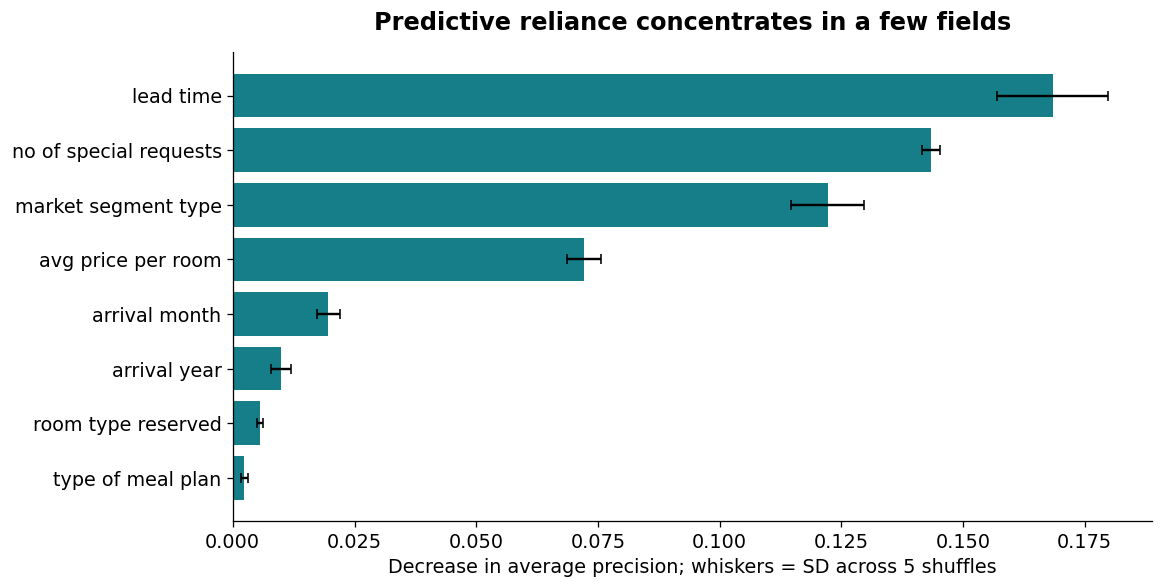

,feature,AP_decrease,repeat_sd
7,lead_time,0.1684,0.0114
16,no_of_special_requests,0.1433,0.0018
11,market_segment_type,0.1222,0.0074
15,avg_price_per_room,0.0721,0.0035
9,arrival_month,0.0196,0.0023
8,arrival_year,0.0099,0.0020
6,room_type_reserved,0.0056,0.0007
4,type_of_meal_plan,0.0024,0.0007


In [55]:
inspection_rows = X_val.sample(n=min(3000, len(X_val)), random_state=SEED).index
importance = permutation_importance(best, X_val.loc[inspection_rows], y_val.loc[inspection_rows],
    scoring='average_precision', n_repeats=5, random_state=SEED, n_jobs=1)
feature_importance = pd.DataFrame({'feature': X.columns,
    'AP_decrease': importance.importances_mean,
    'repeat_sd': importance.importances_std}).sort_values('AP_decrease', ascending=False)
top = feature_importance.head(8).sort_values('AP_decrease')
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.barh(top.feature.str.replace('_', ' '), top.AP_decrease,
        xerr=top.repeat_sd, color=COLORS['teal'], capsize=3)
ax.axvline(0, color=COLORS['gray'], lw=1)
ax.set_xlabel('Decrease in average precision; whiskers = SD across 5 shuffles')
ax.set_title('Predictive reliance concentrates in a few fields')
finish(fig, '08_feature_importance.png')
display(feature_importance.head(8).round(4))

In [56]:
# Remove feature groups in training CV to test dependence on their availability.
derived = ['total_guests', 'total_nights', 'invalid_arrival_date',
           'zero_guests', 'zero_nights', 'zero_room_price']
uncertain = ['no_of_previous_cancellations',
             'no_of_previous_bookings_not_canceled', 'no_of_special_requests']
sensitivity_rows = []
for name, drop in [('all features', []), ('without derived features', derived),
                   ('without timing-uncertain fields', uncertain)]:
    subset = X_fit.drop(columns=drop)
    result = cross_validate(make_model(estimators[winner], subset.columns),
        subset, y_fit, cv=cv, scoring='average_precision', n_jobs=1)
    sensitivity_rows.append({'variant': name, 'mean_AP': result['test_score'].mean(),
                              'sd_AP': result['test_score'].std(ddof=1)})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)
sensitivity.to_csv(OUT / 'training_sensitivity.csv', index=False)


,variant,mean_AP,sd_AP
0,all features,0.830338,0.002829
1,without derived features,0.831273,0.002343
2,without timing-uncertain fields,0.760385,0.006017


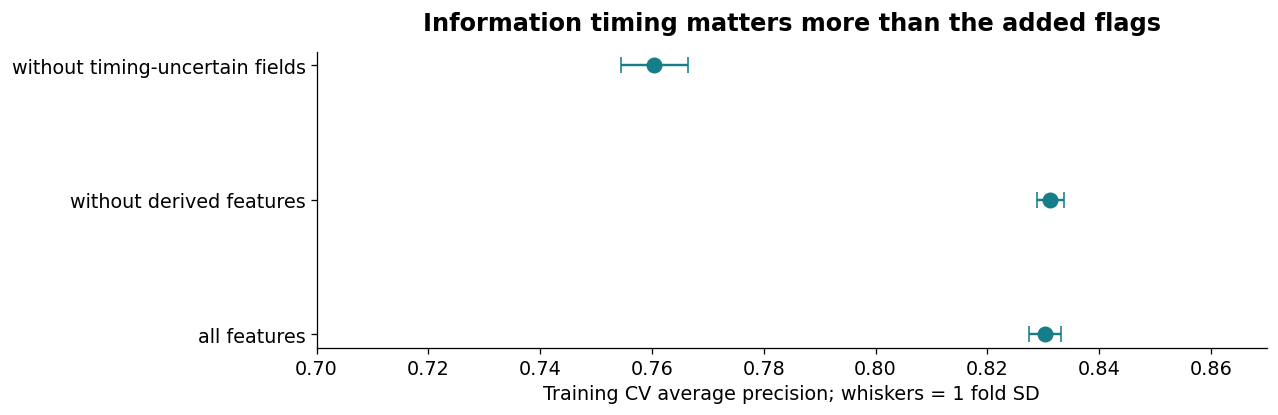

In [57]:
# Display the score change and fold-to-fold spread.
fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.errorbar(sensitivity.mean_AP, np.arange(len(sensitivity)), xerr=sensitivity.sd_AP,
            fmt='o', capsize=5, color=COLORS['teal'], markersize=9)
ax.set_yticks(np.arange(len(sensitivity)), sensitivity.variant)
ax.set_xlim(.70,.87)
ax.set_xlabel('Training CV average precision; whiskers = 1 fold SD')
ax.set_title('Information timing matters more than the added flags')
finish(fig, '09_feature_sensitivity.png')


### Influential features and their timing

The model relies most on **lead time, special requests, market segment, and room price** in the validation importance check. Shuffling a field and seeing performance fall shows reliance, not cause and effect.

When we remove all six added totals and unusual-row flags, training-fold average precision stays about the same (**0.830 → 0.831**). When we remove prior-booking counts and special requests, it falls to **0.760**. That makes their **timing** important: if we promise to score a guest *when they first book*, a special request entered days later cannot be used at that moment. Prior-booking counts are usable only if an accurate history exists then. The data do not record when those values became available. The score drop does **not** prove leakage; it shows that this uncertainty matters.

The grouped feature ablation does not settle whether any single flag is useful. A separate zero-price comparison assesses that decision.


### Zero-price reservations

A price of zero may be a real complimentary booking, a special booking type, or a recording issue. We have no evidence to replace it with a guessed positive price or delete it. The 641 zero-price rows have a much lower observed cancellation rate than other rows, so the condition itself could be informative. We compare three treatments **on the same validation rows**: keep the zero values and flag; keep the zero values without the flag; remove zero-price rows from model fitting. Other anomaly flags and rows stay as they are.

This comparison tests the treatment of zero-price records after model selection. It does not change the selected model or alert cutoff.


In [60]:
# Check the zero-price pattern overall and in the validation subgroup.
zero_price_summary = pd.DataFrame([
    {'sample': sample, 'price group': name, 'rows': int(mask.sum()),
     'canceled': int(labels.loc[mask].sum()),
     'cancellation_rate': labels.loc[mask].mean()}
    for sample, prices, labels in [('all labeled rows', X.avg_price_per_room, y),
                                   ('validation', X_val.avg_price_per_room, y_val)]
    for name, mask in [('zero', prices.eq(0)), ('positive', prices.ne(0))]
])
display(zero_price_summary)


,sample,price group,rows,canceled,cancellation_rate
0,all labeled rows,zero,641,27,0.042122
1,all labeled rows,positive,41459,16477,0.397429
2,validation,zero,115,3,0.026087
3,validation,positive,8305,3298,0.397110


In [61]:
# Fit each variant on the original fitting partition; assess the same validation rows.
zero_val = X_val.avg_price_per_room.eq(0).to_numpy()
variant_specs = [
    ('keep zero and flag', X_fit, y_fit, X_val),
    ('keep zero, remove flag', X_fit.drop(columns='zero_room_price'), y_fit,
     X_val.drop(columns='zero_room_price')),
    ('omit zero rows from fitting', X_fit.loc[X_fit.avg_price_per_room.ne(0)],
     y_fit.loc[X_fit.avg_price_per_room.ne(0)], X_val),
]
zero_variant_rows = []
for name, fit_x, fit_y, val_x in variant_specs:
    candidate = make_model(estimators[winner], fit_x.columns).fit(fit_x, fit_y)
    probability = candidate.predict_proba(val_x)[:, 1]
    zero_variant_rows.append({
        'treatment': name, 'fitting_rows': len(fit_x),
        'validation_AP': average_precision_score(y_val, probability),
        'validation_AUC': roc_auc_score(y_val, probability),
        'validation_Brier': brier_score_loss(y_val, probability),
        'zero_price_mean_prediction': probability[zero_val].mean(),
        'zero_price_Brier': brier_score_loss(y_val.to_numpy()[zero_val], probability[zero_val]),
    })
zero_variant_comparison = pd.DataFrame(zero_variant_rows)
display(zero_variant_comparison)
zero_variant_comparison.to_csv(OUT / 'zero_price_sensitivity.csv', index=False)


,treatment,fitting_rows,validation_AP,validation_AUC,validation_Brier,zero_price_mean_prediction,zero_price_Brier
0,keep zero and flag,25260,0.834591,0.884657,0.134000,0.086622,0.026353
1,"keep zero, remove flag",25260,0.835679,0.884394,0.135153,0.111637,0.034408
2,omit zero rows from fitting,24870,0.834576,0.884350,0.134201,0.196256,0.066027


**Decision.** Retain zero-price reservations and the `zero_room_price` flag. Removing zero-price rows from fitting substantially worsened probability error for that group; removing the flag slightly improved overall average precision but worsened probability error. Only 3 of the 115 zero-price validation bookings canceled, so the subgroup evidence is limited. The other unusual values remain flagged without further repair experiments.


**Interpretation.** The training comparison found negligible benefit from the six derived fields and a substantial loss in AP after removing historical counts and special requests. These experiments test feature sets with the same model family and hyperparameters. They do not identify leakage or establish that a differently tuned reduced model could not improve.

**Method choice.** Each feature-set variant is refitted and compared in training folds. This is a diagnostic of dependence on those fields; the final holdout is not used to choose a variant.

## 10. Fixed-policy holdout performance and uncertainty

The original model and 5:1 validation-selected threshold remain fixed. The holdout comparison shows their workload and error tradeoff against a default cutoff and a prevalence-only baseline.

**Interpretive boundary:** this repeats the previously inspected holdout evaluation. It estimates performance on these reserved observations, with prior exploratory influence acknowledged. It is not independent replication.

In [65]:
# Evaluate the already selected model and policy once on the holdout.
p_hold = best.predict_proba(X_hold)[:, 1]
dummy = make_model(estimators['Dummy'], X.columns).fit(X_fit, y_fit)
holdout = pd.DataFrame({
    'dummy at 0.5': metric_row(y_hold, dummy.predict_proba(X_hold)[:, 1]),
    'selected model at 0.5': metric_row(y_hold, p_hold),
    'selected model at chosen threshold': metric_row(y_hold, p_hold, threshold),
}).T
holdout['illustrative_loss'] = holdout.FP + 5 * holdout.FN
display(holdout)
holdout.to_csv(OUT / 'final_holdout_metrics.csv')
policy_baselines = pd.DataFrame({
    'policy': ['alert nobody', 'alert everybody', 'chosen model threshold'],
    'loss_units': [5 * int(y_hold.sum()), int((y_hold == 0).sum()),
                   int(holdout.loc['selected model at chosen threshold', 'illustrative_loss'])],
})
display(policy_baselines)
policy_baselines.to_csv(OUT / 'holdout_policy_comparison.csv', index=False)


,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,illustrative_loss
dummy at 0.5,0.607957,0.000000,0.000000,0.000000,0.500000,0.392043,0.238345,0.000000,5119.0,0.0,3301.0,0.0,16505.0
selected model at 0.5,0.811995,0.781455,0.722508,0.750826,0.888322,0.835472,0.132600,0.362470,4452.0,667.0,916.0,2385.0,5247.0
selected model at chosen threshold,0.693824,0.564727,0.955468,0.709881,0.888322,0.835472,0.132600,0.663302,2688.0,2431.0,147.0,3154.0,3166.0


,policy,loss_units
0,alert nobody,16505
1,alert everybody,5119
2,chosen model threshold,3166


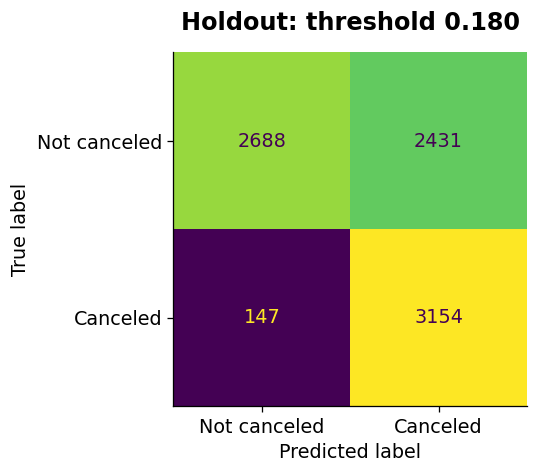

In [66]:
# Show the actual holdout decision counts at the fixed cutoff.
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_hold, p_hold >= threshold,
    display_labels=['Not canceled', 'Canceled'], ax=ax, colorbar=False)
ax.set_title(f'Holdout: threshold {threshold:.3f}')
fig.savefig(OUT / 'holdout_confusion_matrix.png', dpi=160)
plt.show()


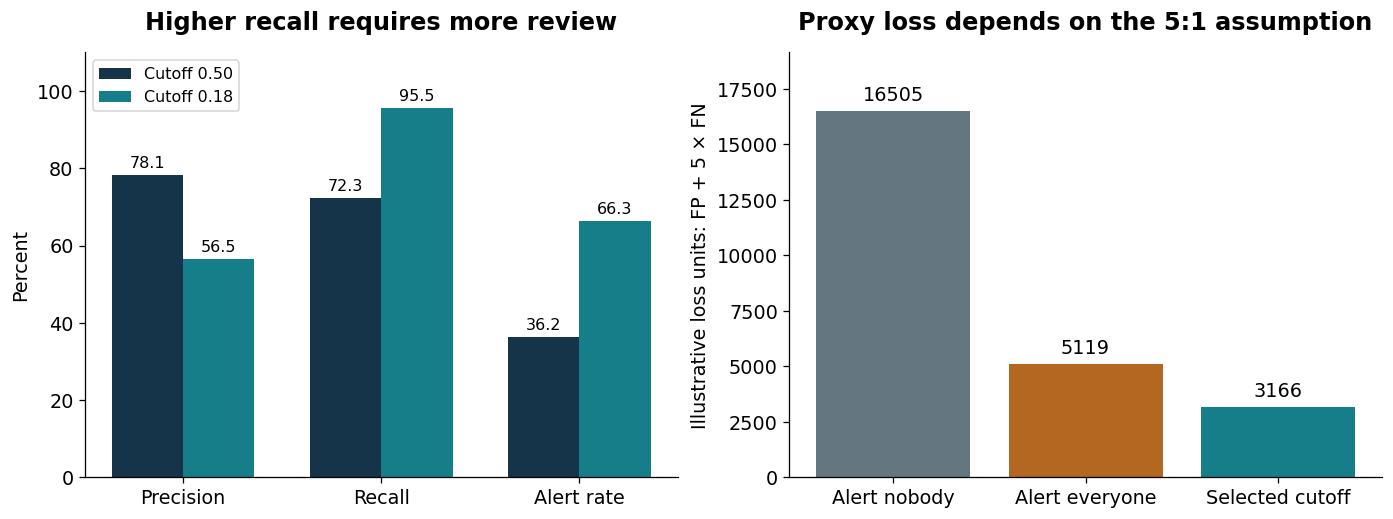

In [67]:
# Compare workload and the illustrative cost with simple policies.
policies = holdout.loc[['selected model at 0.5', 'selected model at chosen threshold']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
xx = np.arange(3)
for i, (name, row) in enumerate(policies.iterrows()):
    values = row[['precision', 'recall', 'alert_rate']].to_numpy(dtype=float)*100
    bars = axes[0].bar(xx+(i-.5)*.36, values, width=.36,
        label='Cutoff 0.50' if i==0 else f'Cutoff {threshold:.2f}',
        color=COLORS['navy'] if i==0 else COLORS['teal'])
    axes[0].bar_label(bars, fmt='%.1f', fontsize=10, padding=3)
axes[0].set_xticks(xx, ['Precision', 'Recall', 'Alert rate'])
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Percent')
axes[0].set_title('Higher recall requires more review')
axes[0].legend(loc='upper left', fontsize=10)
bars = axes[1].bar(['Alert nobody', 'Alert everyone', 'Selected cutoff'], policy_baselines.loss_units,
                  color=[COLORS['gray'], COLORS['amber'], COLORS['teal']])
axes[1].bar_label(bars, padding=4, fmt='%.0f')
axes[1].set_ylim(0, policy_baselines.loss_units.max()*1.16)
axes[1].set_ylabel('Illustrative loss units: FP + 5 × FN')
axes[1].set_title('Proxy loss depends on the 5:1 assumption')
finish(fig, '10_holdout_policy_comparison.png')


In [68]:
# Bootstrap uncertainty for ranking performance of this fixed fitted model.
# Does not include training uncertainty or correct prior exploration bias.
rng = np.random.default_rng(SEED)
labels = y_hold.to_numpy()
boot = []
for _ in range(500):
    idx = rng.integers(0, len(labels), size=len(labels))
    if np.unique(labels[idx]).size == 2:
        boot.append([roc_auc_score(labels[idx], p_hold[idx]),
                     average_precision_score(labels[idx], p_hold[idx])])
intervals = pd.DataFrame(np.quantile(boot, [0.025, 0.975], axis=0).T,
                         index=['ROC_AUC', 'AP'], columns=['lower_95', 'upper_95'])
display(intervals)
intervals.to_csv(OUT / 'holdout_bootstrap_intervals.csv')


,lower_95,upper_95
ROC_AUC,0.881227,0.895090
AP,0.822122,0.847503


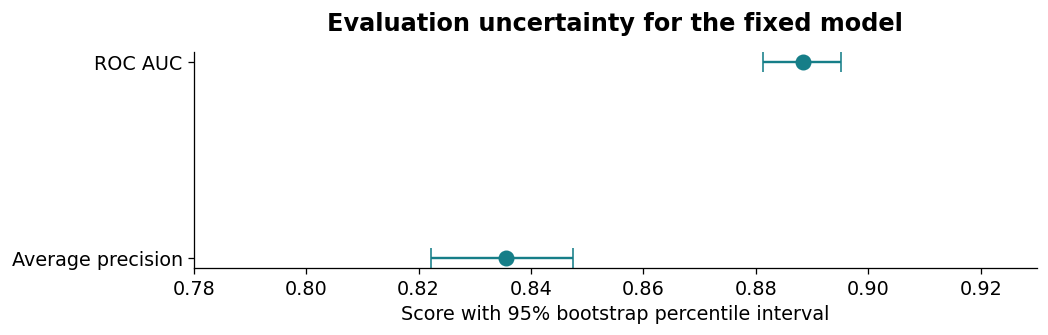

In [69]:
# Show bootstrap intervals for ranking metrics.
fig, ax = plt.subplots(figsize=(9, 2.8), constrained_layout=True)
points = np.array([roc_auc_score(y_hold, p_hold), average_precision_score(y_hold, p_hold)])
ax.errorbar(points, [1,0],
    xerr=[points-intervals.lower_95.to_numpy(), intervals.upper_95.to_numpy()-points],
    fmt='o', capsize=6, markersize=9, color=COLORS['teal'])
ax.set_yticks([1,0], ['ROC AUC', 'Average precision'])
ax.set_xlim(.78,.93)
ax.set_xlabel('Score with 95% bootstrap percentile interval')
ax.set_title('Evaluation uncertainty for the fixed model')
finish(fig, '11_bootstrap_intervals.png')


### Holdout result in practical terms

At the **0.18** cutoff, imagine **100** similar bookings. About **39** would eventually cancel. The rule would flag about **66** bookings: roughly **37** that cancel and **29** that do not. It would miss about **2** cancellations. In the actual 8,420-row holdout, that is **3,154 correctly flagged cancellations**, **2,431 false alerts**, and **147 missed cancellations**.

**Precision (56.5%)** means just over half of flagged bookings canceled. **Recall (95.5%)** means the rule found about 96% of all cancellations. The illustrative loss is lower than alerting everyone or nobody under the assumed 5:1 penalties. It is **not measured savings**. The bootstrap intervals quantify some uncertainty for this fixed model on these rows, not uncertainty about training choices, changing conditions, or contact effectiveness.

**What the uncertainty interval covers.** The bootstrap repeatedly resamples the fixed holdout predictions and outcomes together to estimate variation in ranking metrics. It does not include uncertainty from retraining, choosing the model, earlier exploration, or a shift to new booking periods. The lower illustrative loss does not establish economic benefit.


## 11. Generalization across arrival years

The stress test uses valid-date 2017 arrivals to fit the already selected model family and valid-date 2018 arrivals to evaluate it. It changes the training sample size and outcome prevalence, so it cannot isolate a pure time effect.

Arrival dates are planned dates. A genuine deployment backtest would require booking timestamps, feature histories and the times when cancellation labels became available.

In [73]:
# Train on valid-date 2017 arrivals and test on 2018 arrivals.
arrival = pd.to_datetime({'year': train.arrival_year, 'month': train.arrival_month,
                         'day': train.arrival_date}, errors='coerce')
early = arrival.notna() & train.arrival_year.eq(2017)
later = arrival.notna() & train.arrival_year.eq(2018)
year_model = make_model(estimators[winner], X.columns).fit(X.loc[early], y.loc[early])
p_later = year_model.predict_proba(X.loc[later])[:, 1]
year_stress = pd.DataFrame([metric_row(y.loc[later], p_later, 0.5)])
year_stress['training_rows'] = int(early.sum())
year_stress['evaluation_rows'] = int(later.sum())
year_stress['training_cancellation_rate'] = y.loc[early].mean()
year_stress['evaluation_cancellation_rate'] = y.loc[later].mean()
year_stress['invalid_dates_excluded'] = int(arrival.isna().sum())
display(year_stress)
year_stress.to_csv(OUT / 'arrival_year_stress_test.csv', index=False)


,accuracy,precision,recall,F1,ROC_AUC,AP,Brier,alert_rate,TN,FP,FN,TP,training_rows,evaluation_rows,training_cancellation_rate,evaluation_cancellation_rate,invalid_dates_excluded
0,0.669759,0.77058,0.325068,0.457247,0.770522,0.707836,0.206003,0.180523,19104,1491,10398,5008,6049,36001,0.179368,0.427933,50


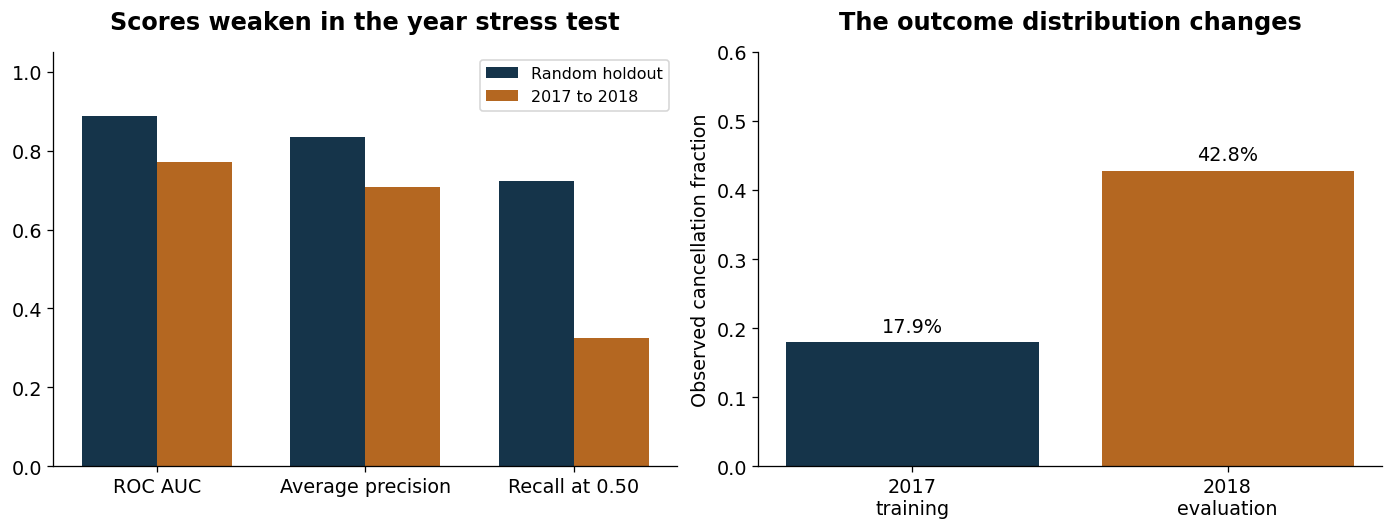

In [74]:
# Compare the temporal stress result with the random holdout.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
metric_names = ['ROC AUC', 'Average precision', 'Recall at 0.50']
random_values = [roc_auc_score(y_hold, p_hold), average_precision_score(y_hold, p_hold),
                 recall_score(y_hold, p_hold>=.5)]
year_values = [year_stress.ROC_AUC.iloc[0], year_stress.AP.iloc[0], year_stress.recall.iloc[0]]
xx = np.arange(3)
axes[0].bar(xx-.18, random_values, .36, label='Random holdout', color=COLORS['navy'])
axes[0].bar(xx+.18, year_values, .36, label='2017 to 2018', color=COLORS['amber'])
axes[0].set_xticks(xx, metric_names)
axes[0].set_ylim(0,1.05)
axes[0].set_title('Scores weaken in the year stress test')
axes[0].legend(fontsize=10)
prev = [y.loc[early].mean(), y.loc[later].mean()]
bars = axes[1].bar(['2017\ntraining', '2018\nevaluation'], prev, color=[COLORS['navy'], COLORS['amber']])
axes[1].bar_label(bars, labels=[f'{v:.1%}' for v in prev], padding=4)
axes[1].set_ylim(0,.6)
axes[1].set_ylabel('Observed cancellation fraction')
axes[1].set_title('The outcome distribution changes')
finish(fig, '12_year_stress_test.png')


### Performance across arrival years

The random holdout mixes 2017 and 2018 bookings, so training and evaluation look relatively similar. In the stress test, the model learns from valid-date **2017 arrivals** and is checked on **2018 arrivals**. ROC AUC drops from about **0.888** in the random holdout to **0.77**; recall at the ordinary 0.50 cutoff drops from **72%** to about **33%**.

This warns us that a result on randomly mixed historical rows may not carry over to a later period. It is not a true booking-time backtest: arrival dates do not tell us when each booking or cancellation was recorded, and the training sample is much smaller.

**Interpretation.** The arrival-year stress test shows ROC AUC declining from about 0.888 to 0.771 and recall at 0.50 declining from 72.3% to 32.5%. This limits the deployment claim. AP also depends on prevalence, so its cross-population comparison needs context.

**Method choice.** A fresh model trains on valid-date 2017 arrivals and is evaluated on 2018 arrivals. Because these rows also appear in the earlier random-split analysis, this is a stress test rather than independent confirmation.

## 12. Recommendation and prospective evaluation

**Recommendation:** test a confirmation-contact policy on genuinely new reservations after resolving feature timing and staffing constraints. Predictive ranking is promising in these historical records, but the observed workload and year shift argue for staged validation.

| Proposed stage | Required evidence | Decision before progressing |
|---|---|---|
| Data readiness | Timestamped feature snapshots and eventual outcomes | Every input exists at the declared scoring time |
| Silent prospective scoring | New-data precision, recall, reliability and workload | Predefined performance and capacity criteria hold |
| Randomized contact pilot | Contact versus usual-practice outcomes among eligible bookings | Estimate incremental benefit and guest impact |
| Operational review | Net benefit, uncertainty, workload and drift | Expand only if predeclared criteria are met |

For a randomized pilot, let $Y(1)$ denote cancellation under contact and $Y(0)$ under usual practice. The eligible-cohort effect is

$$\Delta=E[Y(1)-Y(0)].$$

The current model estimates observed cancellation risk. It does **not** estimate $\Delta$. No treatment-effect estimate or revenue-saving claim follows from the classification metrics.

### Explicit assumption register

| Assumption | Current evidence | Consequence if false | Proposed check |
|---|---|---|---|
| Features exist when scored | Unverified histories | Leakage or unavailable predictors | Audit timestamped snapshots |
| Synthetic patterns transfer | No real-hotel external validation | Lower future performance | New prospective cohort |
| Five-to-one error penalty is appropriate | Illustrative only | Unsuitable threshold and workload | Elicit actual costs and constraints |
| High-risk guests benefit from contact | No intervention data | Accurate alerts without benefit | Randomized pilot |
| Records are sufficiently independent | No guest/group identifier audit | Optimistic uncertainty | Audit grouping and use grouped evaluation |
| Staff can act on the selected alerts | No capacity measurement | Operational overload | Measure daily eligible volume and handling time |

### Graduate-level discussion

1. Why might a model with strong ROC AUC still produce little economic value?
2. How would clustered guests or changing booking channels alter the validation design?
3. What evidence would justify replacing the random split with an event-time backtest?
4. If outreach benefits low-risk guests more, should risk ranking determine whom to contact?

### A path to real-world testing

1. **Score at booking:** use only facts already recorded and verified at that moment. Put near-arrival reservations in the immediate review queue.
2. **Plan later review for far-ahead bookings:** check them again closer to arrival. Refresh the score only when the hotel has timestamped feature histories and has validated the refreshed model.
3. **Watch without acting:** compare prospective scores with eventual outcomes and daily staff capacity.
4. **Test the action:** randomly assign eligible bookings to contact or usual practice to see whether contact changes cancellations or guest experience.

These are proposed next steps, not evaluated hotel operations. No waiting period or guest-contact effect has been tested with these data.


## Methods and sources

**Model settings.** Logistic regression: `C=1`, `max_iter=3000`. Decision tree: `max_depth=6`, `min_samples_leaf=30`. Random forest: 150 trees, `min_samples_leaf=5`, `max_features='sqrt'`. All random operations use seed 42 where supported. Scaling and imputation fit within folds. No competition test data enter model selection.

**References**

1. [Kaggle Playground Series S3E7 data](https://www.kaggle.com/competitions/playground-series-s3e7/data). Source of the synthetic reservation data.
2. [scikit-learn pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html). Fold-specific preprocessing.
3. [scikit-learn probability calibration](https://scikit-learn.org/stable/modules/calibration.html). Reliability and probability scoring.
4. [scikit-learn threshold tuning](https://scikit-learn.org/1.5/modules/classification_threshold.html). Separate probability prediction from the action rule.
5. [scikit-learn permutation importance with correlated features](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html). Limits of individual-feature attribution.

### Key terms

| Term | Say it this way |
|---|---|
| **Feature** | A fact about a booking used for prediction. |
| **Target / label** | The answer we are trying to predict: canceled or not. |
| **Cross-validation** | Repeating practice tests within training data to compare models. |
| **Holdout** | Rows set aside for a final check of the chosen approach. |
| **Average precision** | How well cancellations rise toward the top of a risk-ranked list. |
| **Threshold / cutoff** | The score at which a booking gets flagged. |
| **False alert** | A flagged booking that would not cancel. |
| **Missed cancellation** | A canceled booking that was not flagged. |
| **Data leakage** | Using information that would not actually be available when making the prediction. |
| **Prospective pilot** | Testing the proposed contact process on genuinely new bookings. |

In [81]:
# Export compact results for the report; fitted estimators are not serialized here.
feature_importance.to_csv(OUT/'feature_importance.csv', index=False)
scenario.to_csv(OUT/'cost_sensitivity.csv', index=False)
run_summary = {'selected_model': winner, 'fixed_validation_threshold': threshold,
               'holdout_ROC_AUC': roc_auc_score(y_hold, p_hold),
               'holdout_AP': average_precision_score(y_hold, p_hold),
               'FN_penalty': 5, 'FP_penalty': 1,
               'interpretation': 'Synthetic retrospective evidence; no estimated intervention benefit.'}
(OUT/'run_summary.json').write_text(json.dumps(run_summary, indent=2))
display(pd.Series(run_summary, name='Run summary').to_frame())

,Run summary
selected_model,Random forest
fixed_validation_threshold,0.18
holdout_ROC_AUC,0.888322
holdout_AP,0.835472
FN_penalty,5
FP_penalty,1
interpretation,Synthetic retrospective evidence; no estimated...
